# §4 Individual with ML#2 filter

Per-combo metrics and equity/drawdown curves after applying the V3
booster + pooled-R:R isotonic calibrator filter.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=0.0, top_strategies_path=None)
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Top-K source: top_strategies.json


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Loaded 10 strategies.
Loaded results_raw from cache (10 combos).
Combined unfiltered trades: 11,851


Loaded combos_ml2 from cache (10 combos).
ML2 portfolio trade counts: {'fixed_dollars_500': 5, 'pct5_compound': 5}


In [2]:
rows = []
for cid, entry in s4_pnl_by_combo.items():
    pnl_base = entry['pnl_base']; risk_base = entry['risk_base']
    if len(pnl_base) == 0:
        for policy in POLICIES:
            rows.append({'combo_id': cid, 'policy': policy,
                         **metrics_from_pnl(np.array([]), YEARS_SPAN, policy=policy)})
        continue
    r_mult = np.where(risk_base > 0, pnl_base / risk_base, 0.0)
    for policy in POLICIES:
        pnl = entry['by_policy'][policy]
        rows.append({'combo_id': cid, 'policy': policy,
                     **metrics_from_pnl(pnl, YEARS_SPAN, policy=policy, r=r_mult)})
perf4 = pd.DataFrame(rows)
perf4

,combo_id,policy,n_trades,trades_per_year,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,v10_9955,fixed_dollars_500,101,69.1,0.7228,3.682801e+04,7.366000e+01,5.643500e+00,3.70,2.492350e+03
1,v10_9955,pct5_compound,101,69.1,0.7228,1.586044e+06,3.172090e+03,5.375100e+00,22.62,2.339969e+05
2,v5_2725,fixed_dollars_500,18,12.3,0.8333,6.174160e+03,1.235000e+01,3.122000e+00,2.69,1.485000e+03
3,v5_2725,pct5_compound,18,12.3,0.8333,4.114982e+04,8.230000e+01,3.005800e+00,14.26,1.179168e+04
4,v9_837,fixed_dollars_500,7,4.8,1.0000,3.526900e+03,7.050000e+00,0.000000e+00,0.00,0.000000e+00
5,v9_837,pct5_compound,7,4.8,1.0000,2.085264e+04,4.171000e+01,1.454328e+16,0.00,0.000000e+00
6,v10_4391,fixed_dollars_500,82,56.1,0.9146,6.483785e+04,1.296800e+02,1.749790e+01,0.72,4.988400e+02
7,v10_4391,pct5_compound,82,56.1,0.9146,2.486678e+07,4.973356e+04,1.712150e+01,5.00,3.634233e+05
8,v10_1214,fixed_dollars_500,22,15.1,0.5909,5.133290e+03,1.027000e+01,1.559100e+00,2.79,1.478620e+03
9,v10_1214,pct5_compound,22,15.1,0.5909,3.074408e+04,6.149000e+01,1.448900e+00,14.26,9.538630e+03


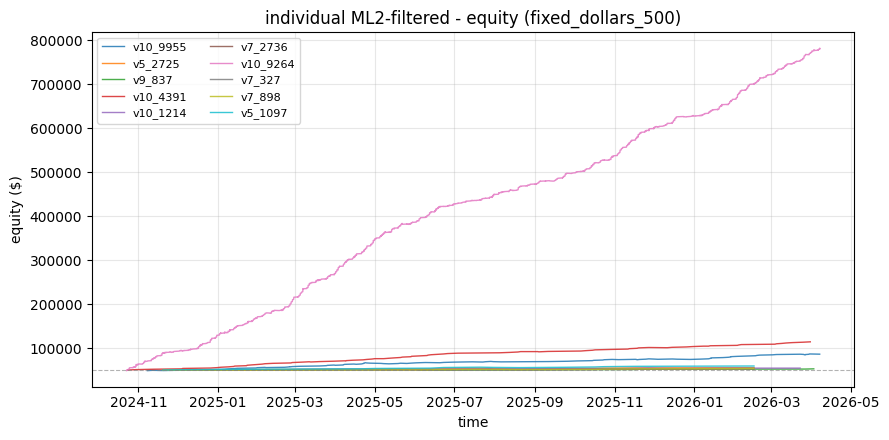

In [3]:
plot_ml2_indiv_equity(s4_pnl_by_combo, bars, 'fixed_dollars_500')

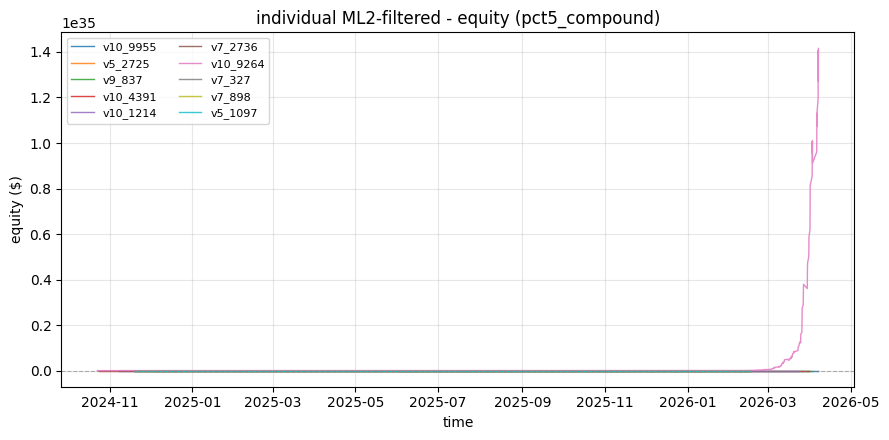

In [4]:
plot_ml2_indiv_equity(s4_pnl_by_combo, bars, 'pct5_compound')

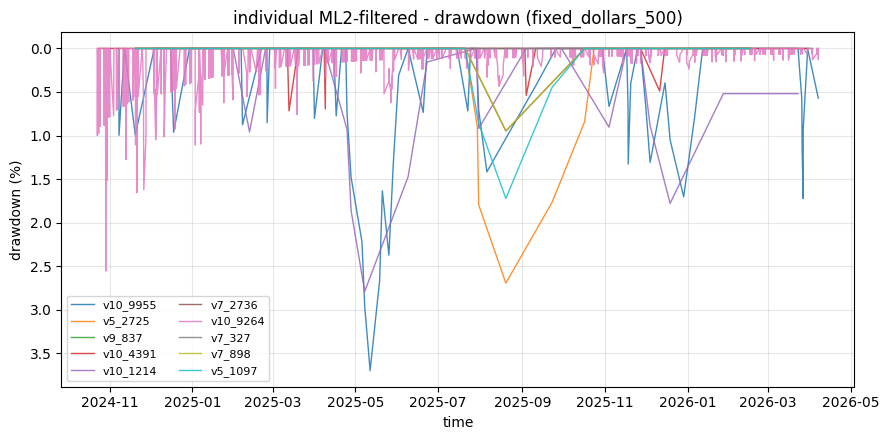

In [5]:
plot_ml2_indiv_dd(s4_pnl_by_combo, bars, 'fixed_dollars_500')

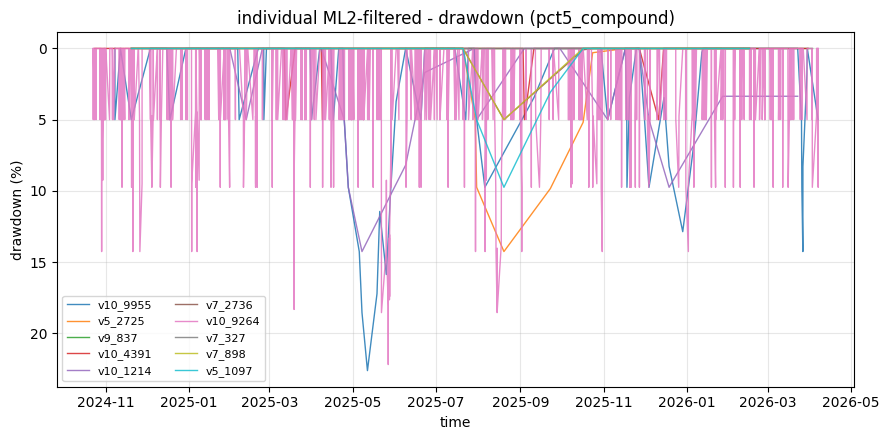

In [6]:
plot_ml2_indiv_dd(s4_pnl_by_combo, bars, 'pct5_compound')